<p align="left">
  <img src="../escudo_uach.png" width="100">
</p>

# Estudio y Experimentación sobre  Amortiguamiento Viscoso

### Integrantes:

* Carlos Durán
* Sebastián Muñoz

## 0. Importar librerías y establecer parámetros para luego

Ambiente listo


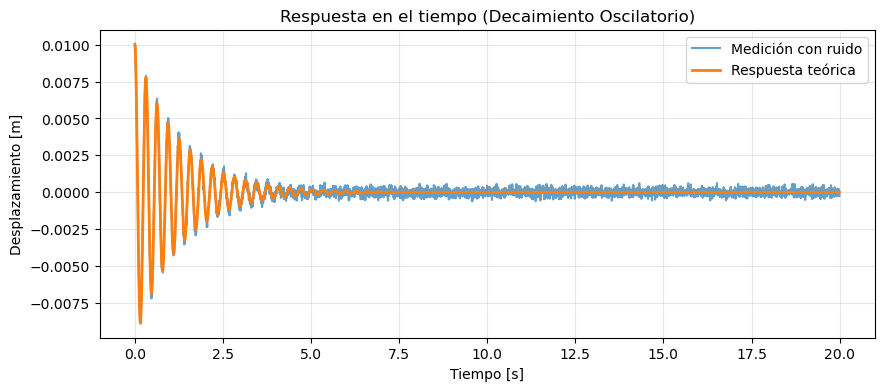

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, find_peaks
try:
    import ipywidgets as widgets
    from ipywidgets import interact
    has_ipywidgets = True
except ModuleNotFoundError:
    has_ipywidgets = False

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 4)
print("Ambiente listo")

# Parámetros físicos
mass = 10.0          # kg
stiffness = 4000.0   # N/m
damping_ratio = 0.04 # Razón de amortiguamiento subamortiguado

omega_n = np.sqrt(stiffness / mass)
omega_d = omega_n * np.sqrt(1 - damping_ratio**2)
fn_hz = omega_n / (2 * np.pi)

# Simulación
sampling_frequency = 200.0
duration = 20.0
t = np.arange(0, duration, 1 / sampling_frequency)

# Respuesta analítica (Caso Subamortiguado)
x_clean = 0.01 * np.exp(-damping_ratio * omega_n * t) * np.cos(omega_d * t)

# Añadir ruido
rng = np.random.default_rng(42)
noise = rng.normal(0.0, 0.02 * np.max(np.abs(x_clean)), size=len(t))
x_noisy = x_clean + noise

plt.plot(t, x_noisy, label="Medición con ruido", alpha=0.7)
plt.plot(t, x_clean, linewidth=2, label="Respuesta teórica")
plt.title("Respuesta en el tiempo (Decaimiento Oscilatorio)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Desplazamiento [m]")
plt.grid(True, alpha=0.3); plt.legend(); plt.show()

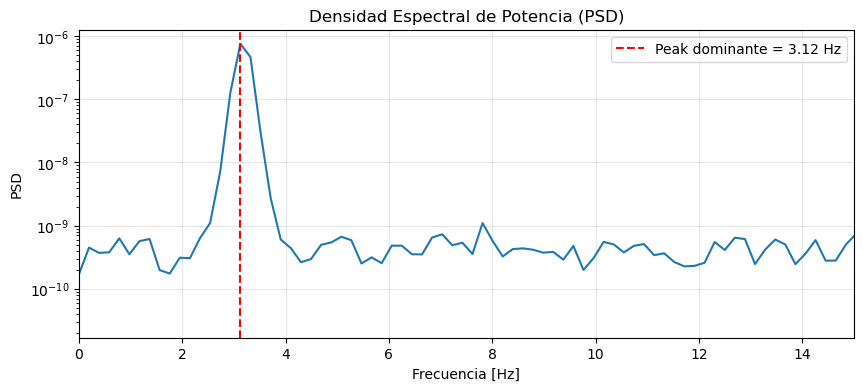

In [6]:
frequencies, psd = welch(x_noisy, fs=sampling_frequency, nperseg=1024, noverlap=512)
dominant_frequency = frequencies[np.argmax(psd)]

plt.semilogy(frequencies, psd)
plt.axvline(dominant_frequency, linestyle="--", color='red', label=f"Peak dominante = {dominant_frequency:.2f} Hz")
plt.title("Densidad Espectral de Potencia (PSD)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD")
plt.xlim(0, 15)
plt.grid(True, alpha=0.3); plt.legend(); plt.show()